# Training Autoencoder Fashion-MNIST di Kaggle
## Eksperimen Latent Dimension 2, 8, dan 32

## Identitas Mahasiswi
**Nama:** Amira Fathinah

**NIM:** 452024618075

**Prodi:** Teknik Informatika / 5

**Kelas:** C1

**Mata Kuliah:** Pemmbelajaran Mesin 2

## 1. Persiapan Library dan Konfigurasi Awal

Bagian ini menyiapkan semua alat yang dipakai untuk training.Pada tahap ini, notebook menyiapkan seluruh library yang dibutuhkan untuk membangun autoencoder, memuat dataset Fashion-MNIST, melakukan training, serta menampilkan hasil visualisasi. Library seperti torch digunakan untuk membangun dan melatih model, sedangkan matplotlib dipakai untuk menampilkan grafik loss dan gambar hasil rekonstruksi. Selain itu, torchvision digunakan untuk mengakses dataset Fashion-MNIST dan melakukan transformasi data sebelum masuk ke model.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.utils import make_grid

Library `os` disiapkan untuk pengelolaan file atau folder. Library `random`, `numpy`, dan `torch` digunakan untuk membantu pengaturan nilai acak agar hasil eksperimen lebih konsisten. `matplotlib.pyplot` berfungsi untuk membuat grafik loss dan menampilkan citra input maupun hasil rekonstruksi. Sementara itu, `torch.nn` dan `torch.optim` digunakan untuk menyusun arsitektur jaringan saraf serta mengatur proses optimasi selama training. `DataLoader` digunakan untuk membaca dataset dalam bentuk batch, sedangkan `datasets` dan `transforms `dari `torchvision` digunakan untuk memuat Fashion-MNIST dan melakukan preprocessing data. `make_grid` nantinya berguna saat menampilkan beberapa gambar dalam satu tampilan.

## 2. Pengaturan Seed dan Device

Setelah library siap, notebook perlu menentukan *seed* dan device yang akan dipakai. *Seed* digunakan agar hasil training lebih konsisten ketika kode dijalankan ulang, sedangkan device menentukan apakah proses training dijalankan menggunakan GPU atau CPU. Pada Kaggle, jika GPU tersedia, training biasanya akan berjalan lebih cepat dan efisien.

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

Fungsi `set_seed(42)` mengatur bilangan acak pada beberapa library supaya hasil eksperimen lebih mudah direplikasi. Nilai 42 digunakan sebagai angka tetap. Setelah itu, variabel `device` dibuat untuk mengecek apakah GPU tersedia. Jika GPU ada, maka cuda akan dipilih. Jika tidak, maka program akan memakai cpu. Dan di sini saya menggunakan CPU.

## 3. Menentukan Parameter Eksperimen
Tahap berikutnya adalah menentukan parameter utama training. Parameter ini mengatur cara model belajar dari data, termasuk ukuran batch, learning rate, jumlah epoch, dan latent dimension. 

In [3]:
batch_size = 128
learning_rate = 1e-3
num_epochs = 10
latent_dim = 2

`batch_size` menentukan jumlah sampel yang diproses dalam satu iterasi training. `learning_rate` mengatur besar langkah pembaruan bobot model pada setiap optimasi. `num_epochs` menentukan berapa kali seluruh dataset akan dilewati oleh model selama training. Sementara itu, `latent_dim` menyatakan ukuran ruang laten yang akan dipakai oleh autoencoder. Pada eksperimen awal ini, latent dimension diset ke 2 terlebih dahulu agar mudah dianalisis, lalu nantinya diubah menjadi 8 dan 32 untuk perbandingan hasil.

## 4. Memuat Dataset Fashion-MNIST

Pada tahap ini, dataset Fashion-MNIST dimuat ke dalam notebook agar model dapat dilatih menggunakan citra pakaian berukuran $28×28$ piksel. Dataset ini berisi gambar grayscale dari berbagai kategori pakaian, sehingga sesuai karena citra relatif sederhana namun tetap memiliki struktur visual yang perlu dipelajari model. Sebelum digunakan, data diubah ke bentuk tensor dan dinormalisasi agar nilainya berada pada rentang yang sesuai untuk proses training jaringan saraf. Setelah dataset dimuat, data dibagi menjadi batch menggunakan `DataLoader` supaya training lebih efisien dan terstruktur.

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 270kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.08MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.5MB/s]


`transforms.Compose` digunakan untuk menyusun beberapa transformasi data secara berurutan. Dalam kode ini, citra hanya diubah menjadi tensor menggunakan `transforms.ToTensor()`, sehingga nilai piksel menjadi bentuk numerik yang dapat diproses oleh PyTorch. `datasets.FashionMNIST` dipakai untuk mengunduh dan memuat dataset Fashion-MNIST. Parameter `train=True` berarti data yang diambil adalah data training, sedangkan `train=False` berarti data testing. Parameter `download=True` membuat dataset otomatis diunduh jika belum tersedia. Setelah itu, `DataLoader` digunakan untuk membagi dataset menjadi batch berukuran `batch_size`, dengan `shuffle=True` pada data training agar urutan data berubah-ubah setiap epoch sehingga model belajar lebih baik.

## 5. Menampilkan Contoh Gambar Fashion-MNIST

Setelah dataset berhasil dimuat, langkah berikutnya adalah menampilkan beberapa contoh gambar untuk memastikan data sudah benar. Tahap ini juga membantu memberikan gambaran awal mengenai bentuk data yang akan dipelajari autoencoder. Karena Fashion-MNIST berisi citra grayscale, tampilan gambar akan sederhana, tetapi tetap cukup untuk menunjukkan pola visual seperti bentuk sepatu, baju, tas, atau celana.

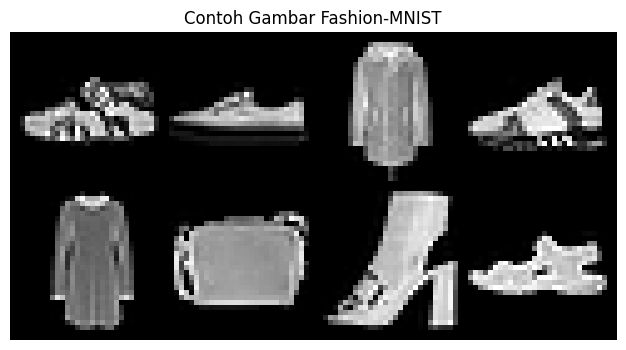

['Sandal', 'Sneaker', 'Coat', 'Sneaker', 'Dress', 'Bag', 'Ankle boot', 'Sandal']


In [5]:
class_names = train_dataset.classes

images, labels = next(iter(train_loader))
grid = make_grid(images[:8], nrow=4)

plt.figure(figsize=(8, 4))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Contoh Gambar Fashion-MNIST")
plt.show()

print([class_names[label] for label in labels[:8]])

`train_dataset.classes` digunakan untuk mengambil nama kelas dari dataset. `next(iter(train_loader))` mengambil satu batch data pertama dari `DataLoader`. Dari batch tersebut, delapan gambar pertama dipilih untuk ditampilkan. Fungsi `make_grid` menyusun beberapa gambar menjadi satu grid agar mudah dilihat sekaligus. Setelah itu, `plt.imshow` digunakan untuk menampilkan grid gambar, sedangkan permute(1, 2, 0) diperlukan agar format tensor sesuai dengan format visualisasi matplotlib. Baris terakhir mencetak nama kelas dari gambar-gambar yang ditampilkan, sehingga kita bisa memverifikasi label setiap citra.

## 6. Definisi Arsitektur Autoencoder

Pada tahap ini, dibuat model autoencoder yang terdiri dari dua bagian utama, yaitu encoder dan decoder. Encoder bertugas mengecilkan citra input menjadi representasi laten berdimensi lebih kecil, sedangkan decoder bertugas membangun kembali citra dari representasi laten tersebut. Struktur seperti ini penting karena autoencoder tidak hanya belajar menyalin gambar, tetapi juga mempelajari fitur-fitur penting yang dianggap paling informatif dari citra input. Ukuran latent dimension pada eksperimen ini dapat diubah menjadi 2, 8, atau 32 sesuai kebutuhan tugas.

In [6]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.view(-1, 1, 28, 28)
        return out

Kelas `Autoencoder` dibuat dengan mewarisi `nn.Module`, yaitu kelas dasar untuk membangun model neural network di PyTorch. Pada bagian `__init__`, parameter `latent_dim` digunakan sebagai ukuran ruang laten yang dapat disesuaikan sesuai eksperimen. Bagian encoder terdiri dari Flatten, Linear, dan ReLU. Flatten mengubah citra 2D berukuran 28×28 menjadi vektor 1 dimensi. Layer Linear(28 * 28, 128) mereduksi dimensi input menjadi 128 fitur, kemudian ReLU memberi non-linearitas agar model lebih fleksibel. Layer terakhir pada encoder, yaitu Linear(128, latent_dim), menghasilkan representasi laten berukuran kecil sesuai nilai latent_dim.

Bagian decoder melakukan proses kebalikan dari encoder. Layer pertama menerima latent vector, lalu mengubahnya kembali menjadi representasi berukuran 128. Setelah itu, layer berikutnya mengembalikan ukuran data menjadi 28×28 piksel. Fungsi aktivasi Sigmoid dipakai agar nilai output berada pada rentang 0 sampai 1, sesuai dengan citra grayscale yang sudah ditransformasi menjadi tensor. Pada fungsi forward, data masuk ke encoder terlebih dahulu untuk menghasilkan latent vector z, lalu latent vector tersebut diproses oleh decoder untuk menghasilkan output rekonstruksi. Hasil akhirnya diubah kembali ke bentuk citra dengan ukuran (-1, 1, 28, 28).

## 7. Membuat Model dan Mengecek Bentuknya

Setelah arsitektur didefinisikan, langkah berikutnya adalah membuat instance model dan memindahkannya ke device yang tersedia. Tahap ini memastikan model siap dipakai untuk training. 

In [7]:
model = Autoencoder(latent_dim=latent_dim).to(device)
model

Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

Penjelasan kode ini adalah sebagai berikut. Baris Autoencoder(latent_dim=latent_dim) membuat model autoencoder dengan ukuran latent dimension yang sudah ditentukan sebelumnya. Setelah itu, .to(device) memindahkan model ke GPU atau CPU sesuai hasil pengecekan device. Menampilkan model di akhir kode bertujuan untuk memastikan bahwa arsitektur telah berhasil dibuat dan siap digunakan.

Output yang diharapkan adalah tampilan struktur model, biasanya berisi daftar layer encoder dan decoder. Dari hasil ini, kita bisa memverifikasi bahwa model memang memiliki layer input, hidden, latent, dan output sesuai rancangan. Dalam laporan, bagian ini bisa dijelaskan sebagai tahap validasi awal sebelum model dilatih, agar tidak ada kesalahan struktur yang baru diketahui di tengah proses training.

## 7. Training Model Autoencoder

Pada tahap ini, model autoencoder dilatih menggunakan data Fashion-MNIST agar dapat mempelajari pola visual dari citra input dan merekonstruksinya kembali dengan baik. Proses training dilakukan dengan cara membandingkan hasil keluaran model dengan citra asli sebagai target, karena pada autoencoder input dan target memang berasal dari gambar yang sama. Loss yang digunakan adalah `MSELoss`, karena tugas autoencoder adalah meminimalkan selisih antara gambar asli dan hasil rekonstruksi. Optimizer yang digunakan adalah `Adam` karena cocok untuk proses training jaringan saraf dengan konvergensi yang relatif stabil.

In [8]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.6f}")

Epoch [1/10] - Loss: 0.045788
Epoch [2/10] - Loss: 0.033052
Epoch [3/10] - Loss: 0.031831
Epoch [4/10] - Loss: 0.031218
Epoch [5/10] - Loss: 0.030789
Epoch [6/10] - Loss: 0.030447
Epoch [7/10] - Loss: 0.030131
Epoch [8/10] - Loss: 0.029856
Epoch [9/10] - Loss: 0.029639
Epoch [10/10] - Loss: 0.029433


Baris `criterion = nn.MSELoss()` menetapkan fungsi loss untuk mengukur seberapa jauh hasil rekonstruksi model dari gambar asli. `optimizer = optim.Adam(...)` digunakan untuk memperbarui bobot model secara bertahap berdasarkan gradien yang dihitung selama training. Variabel `train_losses` disiapkan untuk menyimpan nilai loss pada setiap epoch agar nantinya bisa divisualisasikan dalam bentuk grafik.

Di dalam perulangan `for epoch in range(num_epochs)`, model dijalankan dalam mode training menggunakan `model.train()`. Setiap batch gambar dari `train_loader` dipindahkan ke device agar proses komputasi sesuai dengan GPU atau CPU yang tersedia. Setelah itu, `optimizer.zero_grad()` dipanggil untuk menghapus gradien lama sebelum langkah training baru dimulai. Gambar dimasukkan ke model melalui `outputs = model(images)`, lalu hasil rekonstruksi dibandingkan dengan gambar asli menggunakan `loss = criterion(outputs, images)`. Fungsi `loss.backward()` menghitung gradien, sedangkan `optimizer.step()` memperbarui parameter model. Nilai loss dari setiap batch dijumlahkan ke dalam `running_loss`, lalu dirata-ratakan menjadi `epoch_loss` pada akhir epoch. Nilai ini disimpan ke `train_losses` dan ditampilkan sebagai output agar perkembangan training dapat diamati.

## 8. Visualisasi Grafik Training Loss

Setelah model selesai dilatih, nilai loss pada setiap epoch perlu divisualisasikan agar perkembangan proses training dapat dianalisis dengan lebih mudah. Grafik loss menunjukkan apakah model benar-benar belajar dan apakah penurunan error berlangsung stabil selama training. Pada autoencoder, grafik ini penting karena loss yang menurun menandakan bahwa hasil rekonstruksi semakin mendekati gambar asli.

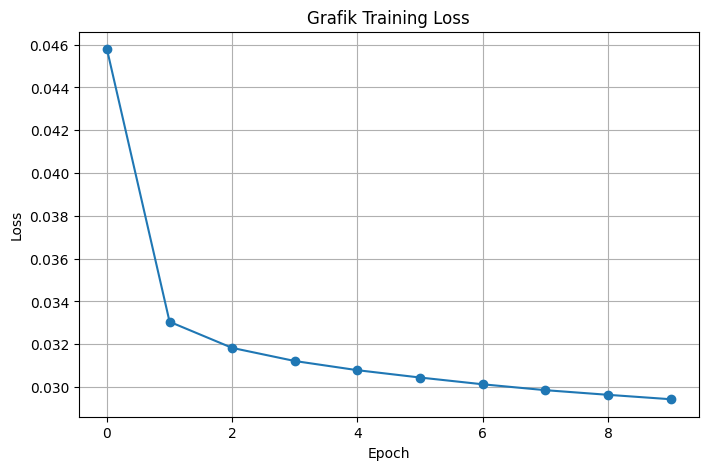

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker='o')
plt.title("Grafik Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

`plt.figure(figsize=(8, 5))` digunakan untuk mengatur ukuran grafik agar lebih mudah dibaca. Fungsi `plt.plot(train_losses, marker='o')` menampilkan perubahan nilai loss dari satu epoch ke epoch berikutnya. `marker='o'` memberi tanda titik pada setiap epoch supaya titik penurunan loss terlihat jelas. Judul grafik dibuat dengan `plt.title`, sedangkan sumbu horizontal diberi label Epoch dan sumbu vertikal diberi label Loss. `plt.grid(True)` menambahkan garis bantu agar grafik lebih mudah dianalisis. Terakhir, `plt.show()` menampilkan grafik ke layar.

## 9. Menampilkan Hasil Rekonstruksi

Pada tahap ini, model diuji menggunakan data yang belum dipakai secara langsung dalam satu langkah training, lalu hasil keluaran dibandingkan dengan gambar asli. Proses ini dilakukan dalam mode evaluasi agar model tidak lagi memperbarui bobot, melainkan hanya melakukan inferensi. Hasil rekonstruksi ini menjadi bagian yang paling penting untuk menilai kualitas autoencoder secara visual, karena nilai loss yang kecil tidak selalu berarti hasil gambar terlihat sangat tajam atau sempurna.

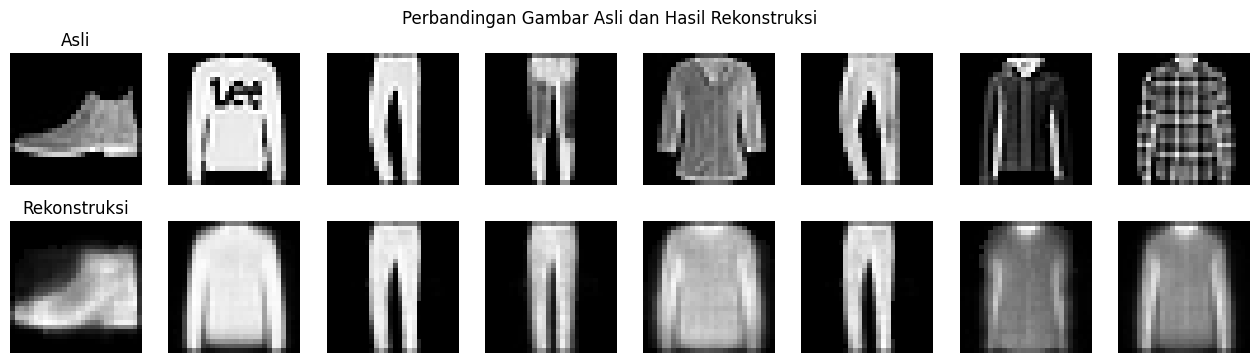

In [10]:
model.eval()

images, labels = next(iter(test_loader))
images = images[:8].to(device)

with torch.no_grad():
    reconstructed = model(images)

images = images.cpu()
reconstructed = reconstructed.cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(8):
    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Asli")

    axes[1, i].imshow(reconstructed[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Rekonstruksi")

plt.suptitle("Perbandingan Gambar Asli dan Hasil Rekonstruksi")
plt.show()

`model.eval()` digunakan untuk mengubah model ke mode evaluasi sehingga layer yang bergantung pada training tidak lagi aktif jika ada. Baris `images, labels = next(iter(test_loader))` mengambil satu batch data dari dataset testing. Delapan gambar pertama dipilih dengan `images[:8]`, lalu dipindahkan ke device agar bisa diproses oleh model. Blok with torch.no_grad() dipakai supaya PyTorch tidak menyimpan gradien, karena pada tahap ini tujuan kita hanya melakukan inferensi, bukan training.

Setelah gambar dimasukkan ke model, hasil rekonstruksi disimpan pada variabel reconstructed. Keduanya kemudian dipindahkan kembali ke CPU agar dapat ditampilkan menggunakan matplotlib. Bagian `plt.subplots(2, 8, figsize=(16, 4))` membuat dua baris gambar, yaitu baris atas untuk gambar asli dan baris bawah untuk hasil rekonstruksi. Perulangan for i in range(8) digunakan untuk menampilkan delapan pasang gambar sekaligus, sehingga perbandingan visual dapat terlihat dengan jelas.

Output yang di tampilkan ada dua baris gambar. Baris pertama berisi gambar asli dari Fashion-MNIST, sedangkan baris kedua berisi hasil rekonstruksi autoencoder. Pada latent dimension yang sangat kecil, hasil rekonstruksi biasanya masih agak buram atau kehilangan detail, dan itu justru bisa dipakai sebagai bahan analisis nanti.

## 10. Menyimpan Model Hasil Training

Setelah model selesai dilatih, langkah selanjutnya adalah menyimpan parameter model ke dalam file dengan format `.pth`. File ini berisi bobot-bobot hasil training yang nantinya dapat dimuat kembali saat menjalankan inferensi atau rekonstruksi dari terminal. Penyimpanan model diperlukan agar proses rekonstruksi tidak harus mengulang training dari awal, sehingga lebih efisien dan sesuai dengan ketentuan tugas. Pada tugas ini, model juga harus dapat digunakan ulang di luar notebook, sehingga penyimpanan menjadi tahap yang wajib dilakukan.

In [12]:
torch.save(model.state_dict(), "autoencoder_fashion_mnist_latent2.pth")
print("Model berhasil disimpan.")

Model berhasil disimpan.


Fungsi `torch.save()` digunakan untuk menyimpan parameter model ke file. Bagian `model.state_dict()` berisi seluruh bobot dan bias hasil training yang telah dipelajari oleh autoencoder. Perintah print() digunakan untuk memberi konfirmasi bahwa proses penyimpanan telah berhasil dilakukan.